# K-Space Hamiltonian and Band Structure

In this section, we will see how to generate the k-space Hamiltonian for a moiré system and compute its band structure. This is essential for understanding the electronic properties of the system, such as the presence of flat bands or Dirac cones.

## 1. Recap and Setup

To work in k-space, **Periodic Boundary Conditions (`pbc=True`) are required**, although not strictly enforced.

In [16]:
import numpy as np
import matplotlib.pyplot as plt
from moirepy import BilayerMoireLattice, HexagonalLayer

In [17]:
lattice = BilayerMoireLattice(
    latticetype=HexagonalLayer,
    ll1=1, ll2=2,
    ul1=2, ul2=1,
    n1=1, n2=1,
    pbc=True  # for k-space
)

twist angle = 0.3803 rad (21.7868 deg)
14 cells in upper lattice
14 cells in lower lattice


## 2. Single k-point Generation

To generate the k space hamiltonian, you first need to generate the real space hamiltonian.

In [18]:
lattice.generate_connections(inter_layer_radius=1)

real_ham = lattice.generate_hamiltonian(
    tll=1, tuu=1,
    tul=1, tlu=1,
    tuself=1, tlself=1
).toarray().real

!!! note
    we convert it to a dense array and take only the real part because the system size is small and the hamiltonian is purely real in this case. For larger systems, it is recommended to work with sparse matrices to save memory and computational resources. While the real-space hopping matrix is real, the k-space Hamiltonian is Hermitian and complex in general.

In [19]:
## Get Moire Lattice Vectors
mlv1 = np.array(lattice.mlv1)  # 1st moire lattice vector
mlv2 = np.array(lattice.mlv2)  # 2nd moire lattice vector
## Compute the 2D cross product (area of the parallelogram)
moire_area = abs(mlv1[0]*mlv2[1] - mlv1[1]*mlv2[0])
print(f"Moire Unit cell Area: {moire_area:.2f}")

Moire Unit cell Area: 6.06


In [20]:
# Prefactor (2π / Area)
prefactor = (2 * np.pi) / moire_area

# Compute K-space lattice vectors
k1 = prefactor * np.array([mlv2[1], -mlv2[0]])  # (lv2_y, -lv2_x)
k2 = prefactor * np.array([-mlv1[1], mlv1[0]])  # (-lv1_y, lv1_x)
print("1st Moire Reciprocal Lattice Vector: ", k1)
print("2nd Moire Reciprocal Lattice Vector: ", k2)
k1_3d = np.append(k1, 0)
k2_3d = np.append(k2, 0)

area = np.linalg.norm(np.cross(k1_3d, k2_3d))
print("Moire Reciprocal Lattice Area: ", area)

1st Moire Reciprocal Lattice Vector:  [2.6927937  0.51822839]
2nd Moire Reciprocal Lattice Vector:  [-1.7951958   2.07291356]
Moire Reciprocal Lattice Area:  6.512250008873207


!!! warning "Manual Hermiticity"
    MoirePy gives you raw control over the hopping directions. To maintain a physical, Hermitian Hamiltonian, you must ensure your `tlu` (Lower to Upper) values are the complex conjugates of your `tul` (Upper to Lower) terms.

!!! note "Phase Factors in k-space"
    We know that to go from real space to k-space, we need to multiply the hopping terms by a phase factor:

    $$H(k)_{ij} = H_{ij} e^{-i k \cdot R}$$

    where $H_{ij}$ is the real space hopping from site $i$ to site $j$. MoirePy keeps the $R$ calculated when u run `lattice.generate_connections` and `lattice.get_phase(k)` will literally return the hamiltonian shaped grid of numbers ($\cos\theta - i \sin\theta$) where $\theta = k \cdot R$.

    However, this phase grid is not complete, it  has 0s for all the places where hamiltonian is zero. To save memory and time, we don't calculate the phase for all pairs of sites.

## 3. Band Structure Calculation (The Physics Payoff)

The primary use of k-space is to visualize how energy levels evolve across the **Moiré Brillouin Zone (MBZ)**.

### Step 1: Define the Path

We sample the zone by interpolating between High-Symmetry points ($\Gamma$, $K$, $Kp$ $M$) in the MBZ. This path captures the essential physics of the system.

In [21]:
# Defined using the reciprocal lattice vectors of the moire system
G = np.array([0, 0])
K = (1/3) * k1 + 2/3 * k2
Kp = 2/3 * k1 + 1/3 * k2
M = (1/2) * k1

def get_path(points, steps=50):
    path = []
    for i in range(len(points) - 1):
        for t in np.linspace(0, 1, steps):
            path.append(points[i] * (1 - t) + points[i + 1] * t)
    return np.array(path)

k_path = get_path([G, K, Kp, M, G])

### Step 2: Find eigenvalues of hamiltonian at each k-point

Since k-space Hamiltonians represent a single unit cell, they are much smaller than real-space matrices. We can use dense solvers like `np.linalg.eigvalsh` for high precision.

In [22]:
bands = []

for k in k_path:
    Hk = real_ham * lattice.get_phase(k).toarray()
    # Convert sparse k-matrix to dense for the eigensolver
    eigvals = np.linalg.eigvalsh(Hk)
    bands.append(eigvals)

bands = np.array(bands)

### Step 3: Visualization

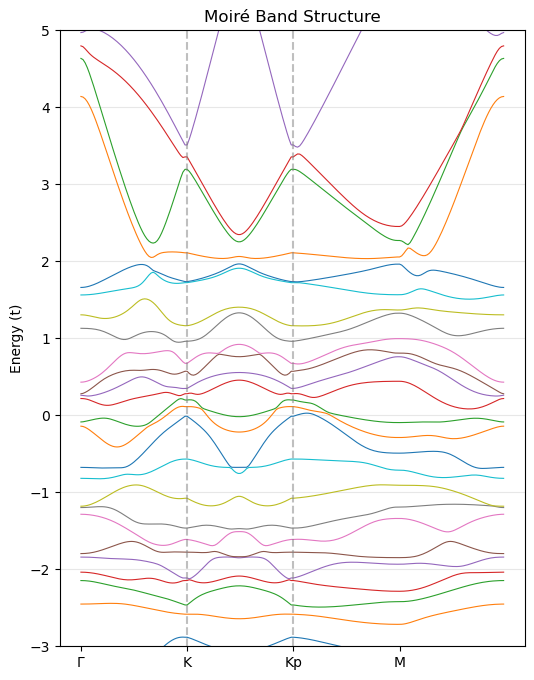

In [24]:
plt.figure(figsize=(6, 8))
# plt.plot(bands, color='black', linewidth=1)
plt.plot(bands, lw=0.8)

# Mark the high-symmetry transitions
plt.axvline(x=50, linestyle='--', color='gray', alpha=0.5)
plt.axvline(x=100, linestyle='--', color='gray', alpha=0.5)

plt.xticks([0, 50, 100, 150], [r'$\Gamma$', 'K', "Kp", 'M'])
# plt.ylim(-4, 4)
plt.ylabel("Energy (t)")
plt.title("Moiré Band Structure")
plt.grid(axis='y', alpha=0.3)
plt.ylim(-3, 5)
plt.show()

## Summary

- We constructed the k-space Hamiltonian from the same lattice definition  
- We sampled momentum space along a high-symmetry path  
- We computed and visualized the band structure  

This is the standard workflow for studying electronic structure in periodic moiré systems.

## Next Steps

1. **[OBC vs PBC](obc_vs_pbc.md)**: Understand how boundary conditions affect the Hamiltonian.  
2. **[Defining Custom Layers](prepare_layers.md)**: Go beyond built-in lattices.  
3. **[Designing Custom Hopping](custom_hoppings.md)**: Introduce realistic physics.  
4. **[Tutorials and Replicated Papers](../examples.md)**: See full physical results.  
